# 실습 5-1 : Feature Selection (mRMR, Boruta)

#### **<실습 개요>**

1. 다중공선성 확인 : 상관행렬 히트맵 시각화
2. mRMR 적용 : 선택/제거된 변수 수 확인, 성능 및 히트맵 비교
3. Boruta 적용 : 선택/제거된 변수 수 확인, 성능 및 히트맵 비교
4. 성능 비교 요약 : 전체 변수 vs mRMR vs Boruta

## 분석 준비

### 주요 라이브러리 호출

In [24]:
# mRMR, boruta 설치
!pip install mrmr-selection boruta

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold

# 회귀 모델 및 성능 평가 지표
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 데이터 분할
from sklearn.model_selection import train_test_split

# Boruta 내부에서 변수 중요도를 계산할 때 사용하는 앙상블 모델
from sklearn.ensemble import RandomForestRegressor

In [26]:
# 회귀 성능 평가 함수 (이후 전체 변수 / mRMR / Boruta 결과를 같은 기준으로 비교하기 위해 정의)
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

---

## 1) 데이터 준비

- 공정 중 여러 구간에서 수집한 센서 통계값(표준편차, 평균, 범위)으로 최종 계측값(Y)을 예측하는 회귀 데이터셋

In [27]:
data = pd.read_csv(("dataset/day5-1_data.csv"), encoding="EUC-KR")
data

,자재구분,END_DATE_TIME,Y,CHAMBER,TAE.STDDEV0,TAE.MEAN0,TAE.RANGE0,PC.STDDEV0,PC.MEAN0,PC.RANGE0,...,TAE.STDDEV9,TAE.MEAN9,TAE.RANGE9,CROT.STDDEV9,CROT.MEAN9,CROT.RANGE9,PC.STDDEV9,PC.MEAN9,PC.RANGE9,PC.RANGE11.1
0,1,2017-09-25 16:18,69,4,0.044554,38.083127,0.254154,0.124753,0.044329,0.439883,...,0.032832,35.011650,0.127077,0,35,0,0.405343,45.124841,3.079182,NaN
1,2,2017-09-25 16:13,28,2,0.034801,38.052395,0.063538,0.177575,0.342131,0.439883,...,0.020858,35.550245,0.063540,0,27,0,1.923012,45.350277,15.004887,NaN
2,3,2017-09-25 16:15,13,3,0.030089,38.046407,0.127080,0.137559,0.063983,0.488759,...,0.021635,36.013373,0.063538,0,15,0,0.161640,45.071393,0.977516,NaN
3,4,2017-09-25 16:10,101,4,0.047904,38.090810,0.190617,1.441465,0.503421,6.549365,...,0.025405,35.020727,0.127077,0,35,0,0.359273,45.110758,2.688171,NaN
4,5,2017-10-05 3:48,319,3,0.036058,38.023829,0.190617,0.116419,0.045446,0.391007,...,0.076083,33.967311,0.317697,0,58,0,0.447676,45.147192,3.225808,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,135,2018-01-25 13:18,27,3,0.027780,38.064804,0.063536,0.306206,0.342131,1.124145,...,0.025479,36.533647,0.127079,0,65,0,0.325076,45.069147,3.176930,3.176930
135,136,2018-01-25 13:10,23,3,0.033961,38.077084,0.063536,0.163848,0.502723,0.488759,...,0.033529,36.548598,0.127079,0,64,0,0.668920,45.131644,5.180838,5.180838
136,137,2018-01-25 13:13,56,3,0.031002,38.068007,0.063536,0.177190,0.481776,0.537634,...,0.026805,36.535092,0.127079,0,64,0,0.613599,44.972303,4.985336,4.985336
137,138,2018-01-25 13:15,78,2,0.031002,38.068007,0.063536,0.170316,0.349113,0.439883,...,0.038289,36.022728,0.127080,0,22,0,1.382720,45.285845,10.801564,10.801564


### 1-1) 전처리

In [28]:
# 식별자, 시간 정보 컬럼과 결측치가 있는 컬럼 제거
data.drop(["자재구분", "END_DATE_TIME"], axis=1, inplace=True)
data.dropna(axis=1, inplace=True)

# 값이 모두 동일해 분산이 0인 변수는 모델 학습에 아무 정보도 주지 못하므로 제거
for col in data.columns:
    if len(data[col].unique()) == 1:
        data.drop([col], axis=1, inplace=True)

print("최종 데이터 크기:", data.shape)

최종 데이터 크기: (139, 117)


In [29]:
X = data.drop("Y", axis=1)
Y = data["Y"]

# random_state를 고정해 이후 mRMR/Boruta 비교 실험이 동일한 학습/검증 데이터로 진행되도록 함
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

---

### 1-2) 다중공선성 확인

> **다중공선성(Multicollinearity)**
>
> 입력변수 간 상관관계가 높아 모델의 안정성과 해석력이 저하되는 현상
>
> **해결 방법**
>
> 차원 축소(Dimensionality Reduction)
> - Feature Selection : mRMR, Boruta
> - Feature Extraction : PCA

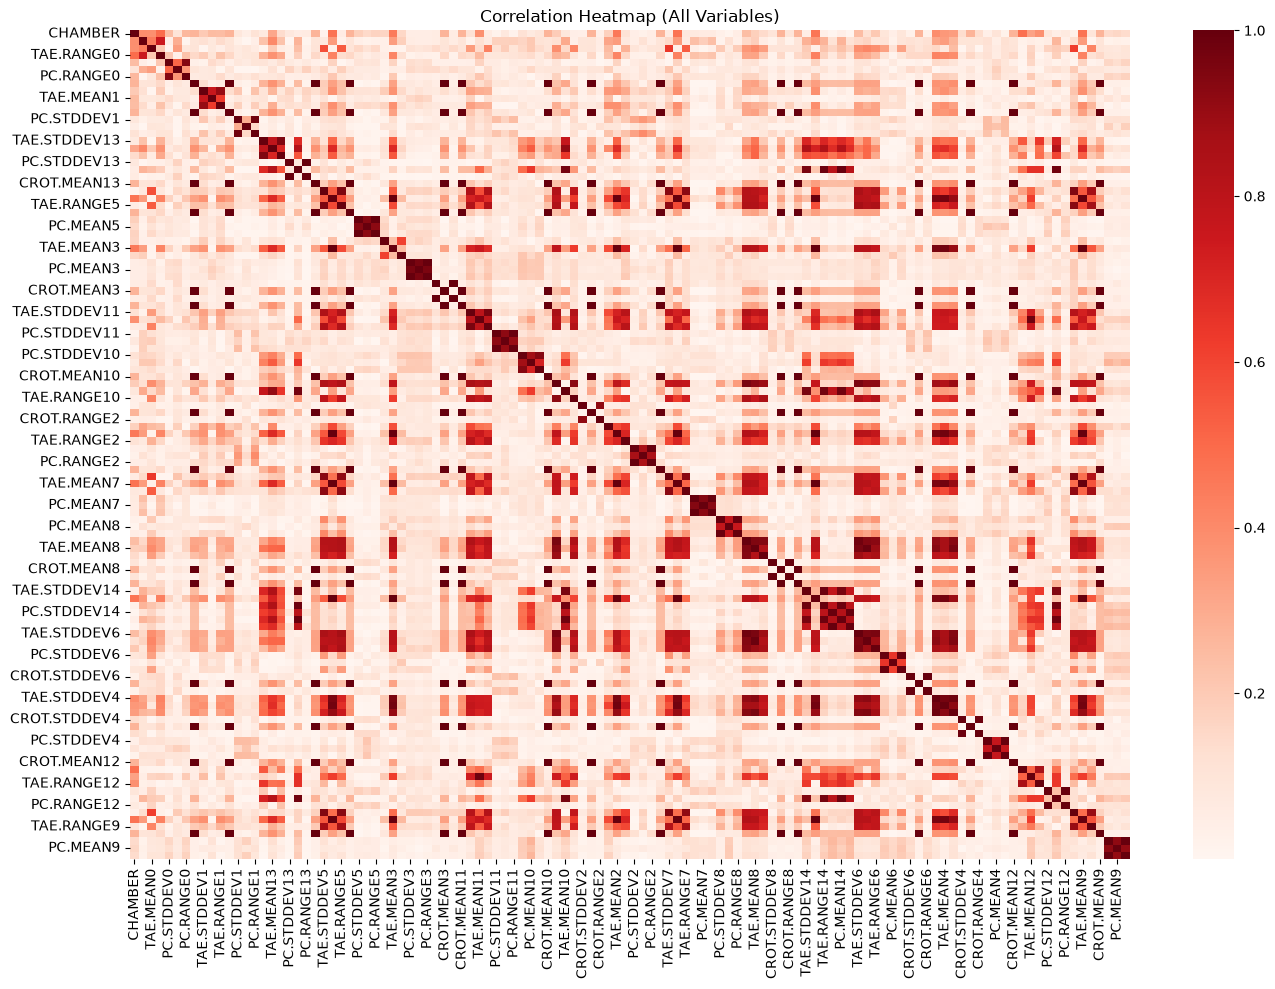

In [30]:
plt.figure(figsize=(14, 10))
sns.heatmap(abs(X.corr()), cmap='Reds')
plt.title("Correlation Heatmap (All Variables)")
plt.tight_layout()
plt.show()

In [31]:
# 변수 선택 전 baseline 성능 (이후 mRMR/Boruta 결과와 비교할 기준점)
lr_all = LinearRegression()
lr_all.fit(X_train, Y_train)
pred_all = lr_all.predict(X_test)
print("[전체 변수 사용]")
get_regscore(Y_test, pred_all)

[전체 변수 사용]
MSE       : 94210.388
MAE       : 213.011
R-squared : -15.511


---

## 2) 변수 선택법 적용

### 2-1) mRMR

> **mRMR**
>
> 입력변수들 간의 상관관계는 **최소화(Minimum Redundancy)** 하고, 입력변수와 출력변수 간의 상관관계는 **최대화(Maximum Relevance)** 하는 변수 선택 방법
> - Pearson 상관계수를 사용하여 변수 간 관계를 파악
> - 하이퍼파라미터 $k$: 선택할 변수의 개수

In [32]:
from mrmr import mrmr_regression

# mRMR로 상위 k개 변수 선택 (하이퍼파라미터)
k = 15
selected_mrmr = mrmr_regression(X_train, Y_train, K=k)
removed_mrmr = [col for col in X.columns if col not in selected_mrmr]

print(f"mRMR 선택 변수 ({len(selected_mrmr)}개):", selected_mrmr)
print(f"mRMR 제거 변수 : {len(removed_mrmr)}개 (전체 {X.shape[1]}개 중 {len(selected_mrmr)}개만 사용)")

100%|██████████| 15/15 [00:00<00:00, 25.60it/s]

mRMR 선택 변수 (15개): ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3', 'CROT.MEAN7', 'TAE.RANGE4', 'CROT.MEAN8', 'PC.STDDEV0', 'CROT.MEAN3', 'TAE.STDDEV4', 'CROT.MEAN0', 'CROT.MEAN13']
mRMR 제거 변수 : 101개 (전체 116개 중 15개만 사용)


In [33]:
# mRMR 기반으로 선택된 변수만으로 다시 학습해 성능 추출
lr_mrmr = LinearRegression()
lr_mrmr.fit(X_train[selected_mrmr], Y_train)
pred_mrmr = lr_mrmr.predict(X_test[selected_mrmr])
print("[mRMR 선택 변수 사용]")
get_regscore(Y_test, pred_mrmr)

[mRMR 선택 변수 사용]
MSE       : 4494.179
MAE       : 44.956
R-squared : 0.212


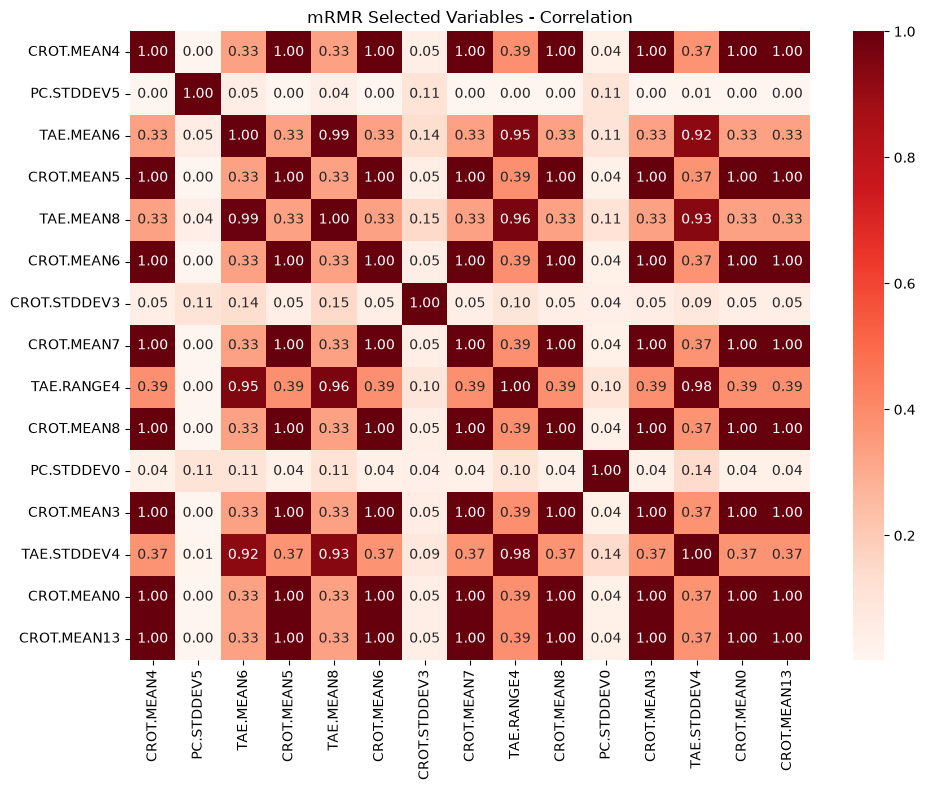

In [34]:
# mRMR 적용 이후 Heatmap 확인
plt.figure(figsize=(10, 8))
sns.heatmap(abs(X[selected_mrmr].corr()), cmap='Reds', annot=True, fmt=".2f")
plt.title("mRMR Selected Variables - Correlation")
plt.tight_layout()
plt.show()

In [35]:
# k-fold cross validation을 활용해 후보 k값들 중 최적의 k값 찾기
k_candidates = [3, 5, 7, 10, 15]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

k_scores = {}

for k in k_candidates:
    # 전체 학습 데이터 기준으로 mRMR 변수 선택 
    selected = mrmr_regression(X_train, Y_train, K=k)
    
    fold_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx][selected], X_train.iloc[val_idx][selected]
        y_tr, y_val = Y_train.iloc[train_idx], Y_train.iloc[val_idx]
        
        model = LinearRegression()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        fold_scores.append(mean_squared_error(y_val, pred)) # MSE 기준
    
    k_scores[k] = np.mean(fold_scores)
    print(f"k={k}, 변수={selected}, 평균 MSE={k_scores[k]:.4f}")

100%|██████████| 3/3 [00:00<00:00, 43.21it/s]


k=3, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6'], 평균 MSE=1827.2074


100%|██████████| 5/5 [00:00<00:00, 35.99it/s]


k=5, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8'], 평균 MSE=1919.6131


100%|██████████| 7/7 [00:00<00:00, 33.86it/s]


k=7, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3'], 평균 MSE=1961.4725


100%|██████████| 10/10 [00:00<00:00, 33.60it/s]


k=10, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3', 'CROT.MEAN7', 'TAE.RANGE4', 'CROT.MEAN8'], 평균 MSE=2199.8306


100%|██████████| 15/15 [00:00<00:00, 31.59it/s]

k=15, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3', 'CROT.MEAN7', 'TAE.RANGE4', 'CROT.MEAN8', 'PC.STDDEV0', 'CROT.MEAN3', 'TAE.STDDEV4', 'CROT.MEAN0', 'CROT.MEAN13'], 평균 MSE=2696.1711


In [36]:
# 가장 성능 좋은(MSE 최소) k 선택
best_k = min(k_scores, key=k_scores.get)
print(f"최적 k: {best_k} (MSE={k_scores[best_k]:.4f})")

# 최적 k로 최종 변수 선택
selected_mrmr = mrmr_regression(X_train, Y_train, K=best_k)
removed_mrmr = [col for col in X.columns if col not in selected_mrmr]

print(f"mRMR 선택 변수 ({len(selected_mrmr)}개):", selected_mrmr)
print(f"mRMR 제거 변수 : {len(removed_mrmr)}개 (전체 {X.shape[1]}개 중 {len(selected_mrmr)}개만 사용)")

최적 k: 3 (MSE=1827.2074)


100%|██████████| 3/3 [00:00<00:00, 42.28it/s]

mRMR 선택 변수 (3개): ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6']
mRMR 제거 변수 : 113개 (전체 116개 중 3개만 사용)


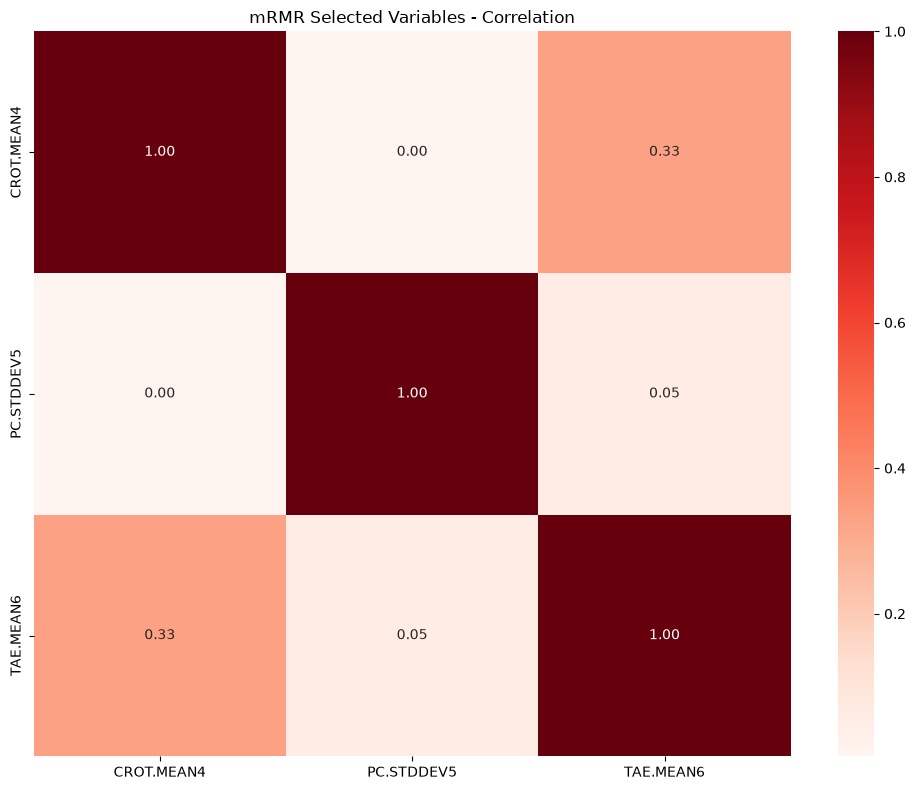

In [37]:
# mRMR를 기반으로 변수를 줄인 뒤 다중공선성이 얼마나 완화됐는지 수치로 확인
plt.figure(figsize=(10, 8))
sns.heatmap(abs(X[selected_mrmr].corr()), cmap='Reds', annot=True, fmt=".2f")
plt.title("mRMR Selected Variables - Correlation")
plt.tight_layout()
plt.show()

In [38]:
# best_k 변수로 최종 학습 후 X_test 성능 평가
lr_mrmr = LinearRegression()
lr_mrmr.fit(X_train[selected_mrmr], Y_train) 
pred_mrmr = lr_mrmr.predict(X_test[selected_mrmr])

print("[mRMR 선택 변수 사용 - Test 성능]")
get_regscore(Y_test, pred_mrmr)

[mRMR 선택 변수 사용 - Test 성능]
MSE       : 3731.451
MAE       : 40.361
R-squared : 0.346


---

### 2-2) Boruta

> **Boruta**
>
> 출력변수를 예측하는 데 필요한 **모든 관련 변수(All Relevant Features)** 를 선택하는 방법
>
> - 입력변수의 값을 무작위로 섞은 **Shadow Feature**를 생성
> - Random Forest로 변수 중요도를 계산하여 Shadow Feature 보다 높은 중요도를 가진 변수만 선택

In [39]:
from boruta import BorutaPy

# n_estimators='auto' : 트리 개수 자동 설정
# max_iter=10 : 반복 판단 횟수 (많을수록 정확하지만 느림)
# perc=100 : 판단 기준 엄격도 (100=가장 엄격, 낮을수록 변수 더 많이 통과)

rf = RandomForestRegressor(random_state=42)
selected_boruta = BorutaPy(rf, n_estimators='auto', max_iter=10, perc=100, random_state=42)

# BorutaPy는 numpy 배열만 지원 -> DataFrame을 values로 변환
# Y는 1차원 배열이어야 하므로 ravel() 적용
selected_boruta.fit(X_train.values, Y_train.values.ravel())

print("총 변수:", X.shape[1])
print("Boruta 확정 변수:", selected_boruta.n_features_)

총 변수: 116
Boruta 확정 변수: 1


> Bourta의 3가지 판단 상태

| 상태 | 의미 | 관련 속성 |
|---|---|---|
| 확정 (Confirmed) | 진짜 유의미한 변수라고 확실히 판단 | `support_` |
| 미정 (Tentative) | 유의미한지 애매하게 끝남 | `support_weak_` |
| 기각 (Rejected) | 의미 없다고 판단 | 둘 다 False |

In [40]:
# 확정 변수(support_)와 판단이 애매한 미정 변수(support_weak_)를 구분해서 확인
boruta_cols = X_train.columns[selected_boruta.support_].tolist()
boruta_tentative = X_train.columns[selected_boruta.support_weak_].tolist()

# 미정 변수 중요도 계산용 랜덤포레스트를 데이터 전체로 별도 학습 (Boruta 내부 rf와 별개)
rf_importance = RandomForestRegressor(random_state=42)
rf_importance.fit(X_train, Y_train)
importances = rf_importance.feature_importances_

tentative_ranked = sorted(boruta_tentative, key=lambda c: importances[X_train.columns.get_loc(c)], reverse=True)

print("확정 변수:", boruta_cols)
print("미정 변수(중요도 순):", tentative_ranked)

확정 변수: ['TAE.MEAN7']
미정 변수(중요도 순): ['TAE.MEAN5', 'TAE.STDDEV13', 'TAE.MEAN10', 'TAE.MEAN12']


In [41]:
# 미정 변수를 0개~5개까지 추가하며 k-fold로 성능 비교
kf = KFold(n_splits=5, shuffle=True, random_state=42)
n_candidates = range(0, min(5, len(tentative_ranked)) + 1)

n_scores = {}

for n in n_candidates:
    use_cols = boruta_cols + tentative_ranked[:n]
    
    fold_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx][use_cols], X_train.iloc[val_idx][use_cols]
        y_tr, y_val = Y_train.iloc[train_idx], Y_train.iloc[val_idx]
        
        model = LinearRegression()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        fold_scores.append(mean_squared_error(y_val, pred))
    
    n_scores[n] = np.mean(fold_scores)
    print(f"미정 변수 {n}개 추가, 평균 MSE={n_scores[n]:.4f}")

미정 변수 0개 추가, 평균 MSE=2530.5618
미정 변수 1개 추가, 평균 MSE=2525.6161
미정 변수 2개 추가, 평균 MSE=2515.9683
미정 변수 3개 추가, 평균 MSE=2675.1350
미정 변수 4개 추가, 평균 MSE=2503.8725


In [42]:
# 최적 개수 선택
best_n = min(n_scores, key=n_scores.get)
print(f"최적 미정 변수 개수: {best_n} (MSE={n_scores[best_n]:.4f})")

최적 미정 변수 개수: 4 (MSE=2503.8725)


In [43]:
# 최적 조합으로 최종 학습 및 Test 평가
selected_boruta_final = boruta_cols + tentative_ranked[:best_n]
print(f"최종 사용 변수 ({len(use_cols)}개):", use_cols)

lr_boruta = LinearRegression()
lr_boruta.fit(X_train[selected_boruta_final], Y_train)
pred_boruta = lr_boruta.predict(X_test[selected_boruta_final])
print("[Boruta 선택 변수 사용 - Test 성능]")
get_regscore(Y_test, pred_boruta)

최종 사용 변수 (5개): ['TAE.MEAN7', 'TAE.MEAN5', 'TAE.STDDEV13', 'TAE.MEAN10', 'TAE.MEAN12']
[Boruta 선택 변수 사용 - Test 성능]
MSE       : 4259.132
MAE       : 47.449
R-squared : 0.254


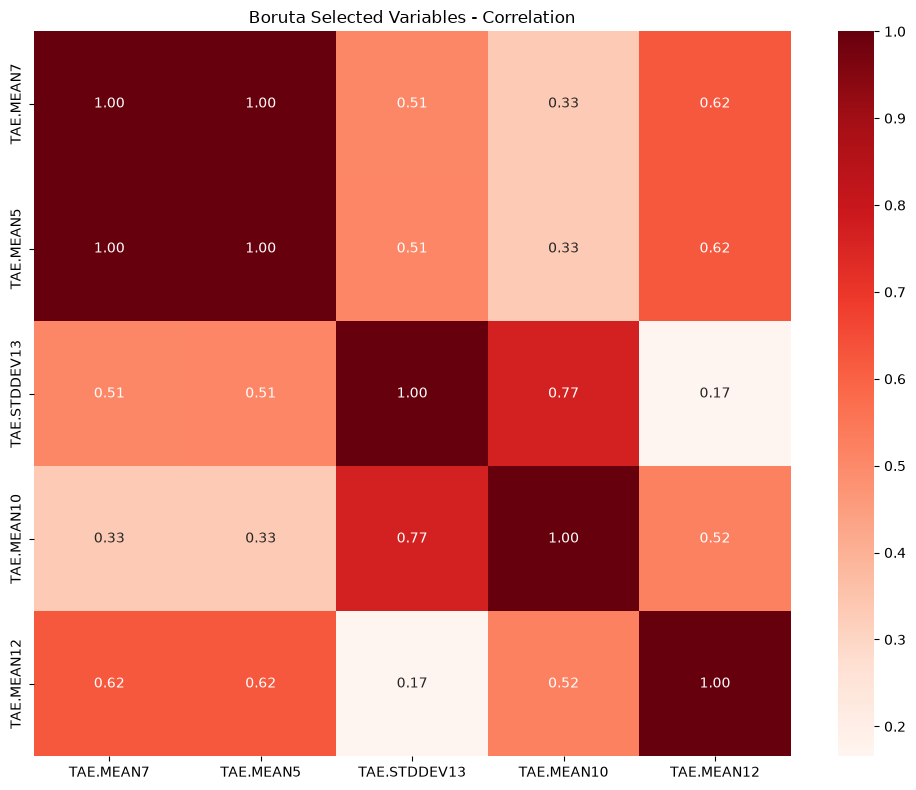

In [44]:
# Boruta를 기반으로 변수를 줄인 뒤 다중공선성이 얼마나 완화됐는지 수치로 확인
plt.figure(figsize=(10, 8))
sns.heatmap(abs(X[selected_boruta_final].corr()), cmap='Reds', annot=True, fmt=".2f")
plt.title("Boruta Selected Variables - Correlation")
plt.tight_layout()
plt.show()

### 2-3) 성능 비교 요약

In [45]:
results = pd.DataFrame({
    "Method": ["전체 변수", f"mRMR (k={best_k})", f"Boruta ({len(selected_boruta_final)}개)"],
    "변수 수": [X.shape[1], best_k, len(use_cols)],
    "MAE": [
        round(mean_absolute_error(Y_test, pred_all), 2),
        round(mean_absolute_error(Y_test, pred_mrmr), 2),
        round(mean_absolute_error(Y_test, pred_boruta), 2)
    ],
    "R-squared": [
        round(r2_score(Y_test, pred_all), 3),
        round(r2_score(Y_test, pred_mrmr), 3),
        round(r2_score(Y_test, pred_boruta), 3)
    ]
})

results

,Method,변수 수,MAE,R-squared
0,전체 변수,116,213.01,-15.511
1,mRMR (k=3),3,40.36,0.346
2,Boruta (5개),5,47.45,0.254


> **분류 문제였다면?**
>
> - mRMR은 `mrmr_regression` → `mrmr_classif`
> - Boruta는 `RandomForestRegressor` → `RandomForestClassifier`

---

## 3) Vibe Coding 실습

**[과제 1]** 

지수는 mRMR과 Boruta가 서로 다른 원리로 변수를 선택한다는 것을 배웠습니다.

AI와 함께 동일한 데이터에 mRMR과 Boruta를 적용하여 선택된 변수를 비교해 보세요. 

두 방법에서 공통으로 선택된 변수와 한 방법에서만 선택된 변수를 확인하고 왜 이러한 차이가 발생했는지 AI와 토의하여 해석해 보세요.

In [46]:
# =============================================================
# mRMR vs Boruta 비교
#  - 동일 dataset(X_train/X_test)을 기준으로 각각 최적 변수만 선택
#  - hyperparameter는 K-Fold CV 성능 지표(R^2)가 가장 높은 값으로 선택
#  - 선택된 최적 변수 / test 성능을 표로 비교
# =============================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_r2(cols):
    """주어진 변수 집합으로 K-Fold CV 평균 R^2 계산 (높을수록 좋음)"""
    scores = []
    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx][cols], X_train.iloc[val_idx][cols]
        y_tr, y_val = Y_train.iloc[tr_idx], Y_train.iloc[val_idx]
        m = LinearRegression().fit(X_tr, y_tr)
        scores.append(r2_score(y_val, m.predict(X_val)))
    return np.mean(scores)

def test_scores(cols):
    """선택된 변수로 최종 학습 후 test 성능(MAE, R^2) 반환"""
    m = LinearRegression().fit(X_train[cols], Y_train)
    pred = m.predict(X_test[cols])
    return mean_absolute_error(Y_test, pred), r2_score(Y_test, pred)

# -------------------------------------------------------------
# 1) mRMR : k 후보 중 CV R^2 최대인 k 선택
# -------------------------------------------------------------
k_candidates = [3, 5, 7, 10, 15]
mrmr_cv = {}
for k in k_candidates:
    cols = mrmr_regression(X_train, Y_train, K=k)
    mrmr_cv[k] = cv_r2(cols)
    print(f"[mRMR] k={k:>2}, CV R^2={mrmr_cv[k]:.4f}")

best_k = max(mrmr_cv, key=mrmr_cv.get)
mrmr_best_cols = mrmr_regression(X_train, Y_train, K=best_k)
print(f"\n>>> mRMR 최적 hyperparameter: k={best_k} (CV R^2={mrmr_cv[best_k]:.4f})\n")

# -------------------------------------------------------------
# 2) Boruta : 확정 변수 + 미정 변수 추가 개수(n) 중 CV R^2 최대인 조합 선택
# -------------------------------------------------------------
rf = RandomForestRegressor(random_state=42)
boruta = BorutaPy(rf, n_estimators='auto', max_iter=10, perc=100, random_state=42)
boruta.fit(X_train.values, Y_train.values.ravel())

confirmed = X_train.columns[boruta.support_].tolist()
tentative = X_train.columns[boruta.support_weak_].tolist()

# 미정 변수는 RandomForest 중요도 순으로 정렬 후 위에서부터 추가
rf_imp = RandomForestRegressor(random_state=42).fit(X_train, Y_train)
imp = rf_imp.feature_importances_
tentative_ranked = sorted(tentative, key=lambda c: imp[X_train.columns.get_loc(c)], reverse=True)

boruta_cv = {}
for n in range(0, min(5, len(tentative_ranked)) + 1):
    cols = confirmed + tentative_ranked[:n]
    if len(cols) == 0:      # 확정/미정 모두 0개면 스킵
        continue
    boruta_cv[n] = cv_r2(cols)
    print(f"[Boruta] 미정 {n}개 추가 (총 {len(cols)}개), CV R^2={boruta_cv[n]:.4f}")

best_n = max(boruta_cv, key=boruta_cv.get)
boruta_best_cols = confirmed + tentative_ranked[:best_n]
print(f"\n>>> Boruta 최적 hyperparameter: 미정 변수 {best_n}개 추가 (CV R^2={boruta_cv[best_n]:.4f})\n")

# -------------------------------------------------------------
# 3) 비교 표 : 선택된 최적 변수 / test 성능
# -------------------------------------------------------------
mrmr_mae, mrmr_r2 = test_scores(mrmr_best_cols)
boruta_mae, boruta_r2 = test_scores(boruta_best_cols)

compare = pd.DataFrame({
    "Method": ["mRMR", "Boruta"],
    "Best Hyperparameter": [f"k={best_k}", f"미정 변수 {best_n}개 추가"],
    "선택 변수 수": [len(mrmr_best_cols), len(boruta_best_cols)],
    "선택된 최적 변수": [", ".join(mrmr_best_cols), ", ".join(boruta_best_cols)],
    "Test MAE": [round(mrmr_mae, 3), round(boruta_mae, 3)],
    "Test R-squared": [round(mrmr_r2, 3), round(boruta_r2, 3)],
})

# 두 방법의 공통 / 고유 변수도 함께 확인
common = sorted(set(mrmr_best_cols) & set(boruta_best_cols))
only_mrmr = sorted(set(mrmr_best_cols) - set(boruta_best_cols))
only_boruta = sorted(set(boruta_best_cols) - set(mrmr_best_cols))
print(f"공통 선택 변수 ({len(common)}개): {common}")
print(f"mRMR에서만 선택 ({len(only_mrmr)}개): {only_mrmr}")
print(f"Boruta에서만 선택 ({len(only_boruta)}개): {only_boruta}")

pd.set_option("display.max_colwidth", None)
compare

100%|██████████| 3/3 [00:00<00:00, 38.28it/s]


[mRMR] k= 3, CV R^2=0.3004


100%|██████████| 5/5 [00:00<00:00, 35.40it/s]


[mRMR] k= 5, CV R^2=0.2575


100%|██████████| 7/7 [00:00<00:00, 36.43it/s]


...

100%|██████████| 15/15 [00:00<00:00, 32.94it/s]


[mRMR] k=15, CV R^2=0.0025


100%|██████████| 3/3 [00:00<00:00, 42.57it/s]



>>> mRMR 최적 hyperparameter: k=3 (CV R^2=0.3004)

[Boruta] 미정 0개 추가 (총 1개), CV R^2=0.0344
[Boruta] 미정 1개 추가 (총 2개), CV R^2=0.0451
[Boruta] 미정 2개 추가 (총 3개), CV R^2=0.0642
[Boruta] 미정 3개 추가 (총 4개), CV R^2=0.0095
[Boruta] 미정 4개 추가 (총 5개), CV R^2=0.0579

>>> Boruta 최적 hyperparameter: 미정 변수 2개 추가 (CV R^2=0.0642)

공통 선택 변수 (0개): []
mRMR에서만 선택 (3개): ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6']
Boruta에서만 선택 (3개): ['TAE.MEAN5', 'TAE.MEAN7', 'TAE.STDDEV13']


,Method,Best Hyperparameter,선택 변수 수,선택된 최적 변수,Test MAE,Test R-squared
0,mRMR,k=3,3,"CROT.MEAN4, PC.STDDEV5, TAE.MEAN6",40.361,0.346
1,Boruta,미정 변수 2개 추가,3,"TAE.MEAN7, TAE.MEAN5, TAE.STDDEV13",46.180,0.221


### mRMR과 Boruta의 최적 변수가 다른 이유

두 방법은 **선택 목표 자체가 다르기 때문에** 남기는 변수가 달라집니다.

| 구분 | mRMR | Boruta |
|---|---|---|
| 선택 목표 | **최소 중복 + 최대 관련성** (Minimal-Redundancy Maximal-Relevance) | **모든 관련 변수** (All-Relevant) |
| 관계 측정 | Pearson 상관계수 (선형 관계) | Random Forest 변수 중요도 (비선형·상호작용 포함) |
| 변수 개수 | 하이퍼파라미터 `k`로 **미리 고정** | 데이터가 결정 (Shadow Feature 통과 여부) |
| 중복 변수 처리 | 서로 상관 높은 변수는 **하나만 남기고 제거** | 각각 유의미하면 **둘 다 남길 수 있음** |

**1. 선택 기준(원리)이 다름**
- **mRMR**: Y와의 관련성이 높으면서 이미 뽑힌 변수와는 상관이 낮은 변수를 우선합니다. 즉 정보가 겹치는(다중공선성이 큰) 변수는 의도적으로 배제합니다.
- **Boruta**: 무작위로 섞은 Shadow Feature보다 중요도가 높은 변수를 "관련 있음"으로 모두 통과시킵니다. 변수끼리 상관이 높아도 각각 예측에 기여하면 함께 남깁니다.

**2. 관계를 재는 방식이 다름**
- mRMR은 **선형(Pearson) 상관**만 보므로 비선형 관계를 놓칠 수 있습니다.
- Boruta는 **Random Forest 기반 중요도**를 쓰므로 비선형·변수 간 상호작용까지 반영합니다. 그래서 mRMR이 버린 변수를 Boruta는 유의미하다고 판단할 수 있습니다.

**3. 변수 개수 결정 방식이 다름**
- mRMR은 `k`개로 개수가 강제 고정되어, `k`보다 관련 변수가 많으면 잘리고 적으면 상대적으로 덜 중요한 변수까지 포함됩니다.
- Boruta는 개수 제한 없이 통계적으로 유의한 변수만 남기므로, 선택 변수 수 자체가 mRMR과 달라집니다.

**4. 중복(다중공선성) 변수의 운명이 다름**
- 서로 강하게 상관된 A, B가 있을 때 mRMR은 **A만** 남기지만, Boruta는 둘 다 예측에 기여하면 **A, B 모두** 남깁니다. 이 차이가 두 방법의 선택 변수 집합을 크게 벌립니다.

> **정리**: mRMR은 "겹치지 않는 핵심 변수 소수"를, Boruta는 "예측에 조금이라도 관련된 변수 전부"를 지향합니다. 목표·관계 측정 방식·개수 결정 방식·중복 처리 방식이 모두 다르기 때문에 최종적으로 선택되는 최적 변수가 서로 달라집니다. (위 셀의 *공통 / 고유 변수* 출력에서 이 차이를 직접 확인할 수 있습니다.)